In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
data = pd.read_csv("../Customer-Segmentation/rfm data/rfm.csv")
df=pd.DataFrame(data)
df.head()

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories,Avg_Discount_Rate,Total_Profit
0,1,793,1,499.950012,499.950012,NaN,NaN,NaN
1,2,137,4,1819.730034,454.932508,1.0,0.06,159.690002
2,3,230,5,3537.680094,707.536019,3.0,0.13,208.739999
3,4,381,4,1719.630030,429.907507,4.0,0.11,334.489999
4,5,458,3,1274.750023,424.916674,4.0,0.14,-439.979992


In [15]:
df.head(10)

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories,Avg_Discount_Rate,Total_Profit
0,1,793,1,499.950012,499.950012,NaN,NaN,NaN
1,2,137,4,1819.730034,454.932508,1.0,0.06,159.690002
2,3,230,5,3537.680094,707.536019,3.0,0.13,208.739999
3,4,381,4,1719.630030,429.907507,4.0,0.11,334.489999
4,5,458,3,1274.750023,424.916674,4.0,0.14,-439.979992
5,6,647,4,3259.510025,814.877506,3.0,0.14,309.850002
6,7,221,7,5569.480106,795.640015,4.0,0.11,893.649998
7,8,127,8,3763.500042,470.437505,5.0,0.12,964.889986
8,9,141,5,3229.680056,645.936011,5.0,0.09,529.930005
9,10,308,2,1264.790012,632.395006,5.0,0.10,-383.879999


In [6]:
model_features = ["Recency","Frequency","Monetary","Avg_Discount_Rate","Unique_Product_Categories","Total_Profit"]
X = df[model_features].dropna().copy()

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(20546, 6)


In [8]:
inertia = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

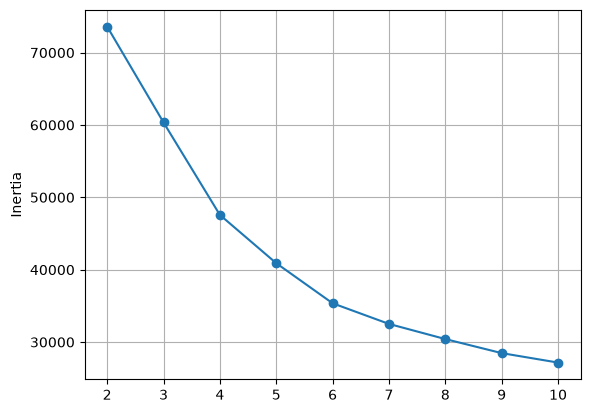

In [9]:
plt.plot(k_values, inertia, marker="o")
plt.xticks(k_values)
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [10]:
kmeans_5 = KMeans(n_clusters=5,random_state=42,n_init=10)
clusters_5 = kmeans_5.fit_predict(X_scaled)

In [11]:
X_5 = X.copy()
X_5["Cluster"] = clusters_5
print(X_5.head())

   Recency  Frequency     Monetary  Avg_Discount_Rate  \
1      137          4  1819.730034               0.06   
2      230          5  3537.680094               0.13   
3      381          4  1719.630030               0.11   
4      458          3  1274.750023               0.14   
5      647          4  3259.510025               0.14   

   Unique_Product_Categories  Total_Profit  Cluster  
1                        1.0    159.690002        2  
2                        3.0    208.739999        3  
3                        4.0    334.489999        0  
4                        4.0   -439.979992        1  
5                        3.0    309.850002        1  


In [12]:
cluster_percentage = (X_5["Cluster"].value_counts(normalize=True).sort_index().mul(100))
print(cluster_percentage.round(2))

Cluster
0    22.33
1    14.96
2    23.19
3    20.95
4    18.57
Name: proportion, dtype: float64


In [13]:
cluster_profile = (X_5.groupby("Cluster").mean().round(2))
print(cluster_profile)

         Recency  Frequency  Monetary  Avg_Discount_Rate  \
Cluster                                                    
0         264.18       4.29   2474.23               0.10   
1         559.10       2.77   1557.18               0.10   
2          67.26       1.07    342.14               0.05   
3         239.75       6.49   4053.62               0.10   
4          65.58       1.05    333.62               0.17   

         Unique_Product_Categories  Total_Profit  
Cluster                                           
0                             4.48        633.61  
1                             4.05        151.34  
2                             1.07         32.35  
3                             3.90         76.60  
4                             1.06         28.60  


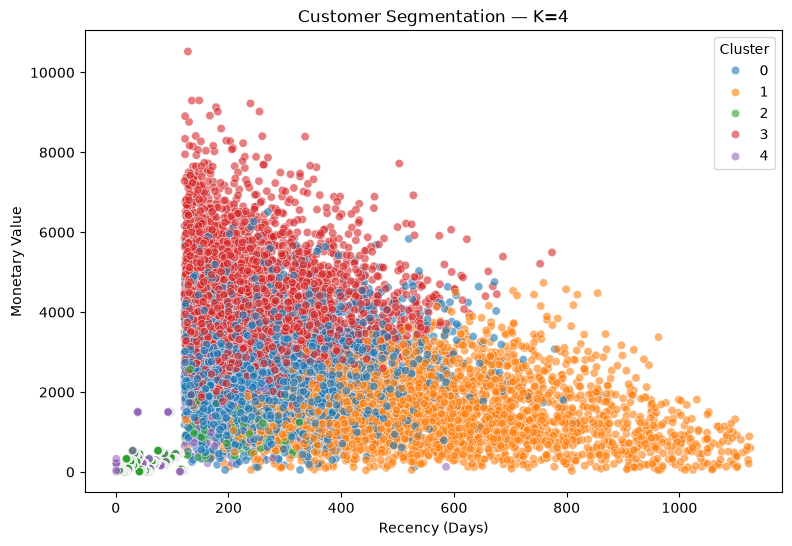

In [14]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=X_5,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    alpha=0.6
)

plt.title("Customer Segmentation — K=4")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary Value")

plt.show()

In [121]:
# Add cluster labels
df_clustered = df.loc[X_5.index].copy()
df_clustered["Cluster"] = clusters_5


# Average customer behavior
final_profile = df_clustered.groupby("Cluster")[
    ["Recency","Frequency","Monetary","Avg_Order_Value","Avg_Discount_Rate","Unique_Product_Categories","Total_Profit"]
].mean()

# Number of customers
final_profile["Customer_Count"] = (df_clustered.groupby("Cluster")["Customer Id"].count())

# Total revenue
final_profile["Total_Revenue"] = (df_clustered.groupby("Cluster")["Monetary"].sum())

# Customer percentage
final_profile["Customer_Percentage"] = (final_profile["Customer_Count"]/ final_profile["Customer_Count"].sum()* 100)

# Total profit
final_profile["Total_Profit"] = (df_clustered.groupby("Cluster")["Total_Profit"].sum())

# Profit contribution
final_profile["Profit_Contribution"] = (final_profile["Total_Profit"]/ final_profile["Total_Profit"].sum()* 100)

# Round values
final_profile = final_profile.round(2)

print(final_profile)

         Recency  Frequency  Monetary  Avg_Order_Value  Avg_Discount_Rate  \
Cluster                                                                     
0         264.18       4.29   2474.23           583.04               0.10   
1         559.10       2.77   1557.18           567.92               0.10   
2          67.26       1.07    342.14           306.70               0.05   
3         239.75       6.49   4053.62           632.09               0.10   
4          65.58       1.05    333.62           306.03               0.17   

         Unique_Product_Categories  Total_Profit  Customer_Count  \
Cluster                                                            
0                             4.48    2906383.30            4587   
1                             4.05     465233.83            3074   
2                             1.07     154131.60            4765   
3                             3.90     329743.36            4305   
4                             1.06     109099.88    

In [122]:
X = X_5.drop("Cluster", axis=1)
y = X_5["Cluster"]

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16436, 6)
Testing data: (4110, 6)


In [124]:
rf_model = RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [125]:
y_pred_rf = rf_model.predict(X_test)

In [126]:
accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.975425790754258


In [127]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       918
           1       0.97      0.96      0.96       615
           2       0.99      0.99      0.99       953
           3       0.96      0.97      0.97       861
           4       1.00      0.98      0.99       763

    accuracy                           0.98      4110
   macro avg       0.98      0.97      0.97      4110
weighted avg       0.98      0.98      0.98      4110



In [128]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Avg_Discount_Rate            0.261849
Recency                      0.209938
Total_Profit                 0.168391
Frequency                    0.134620
Monetary                     0.124595
Unique_Product_Categories    0.100606
dtype: float64


In [132]:
import joblib

joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Models saved successfully!")

Models saved successfully!
